In [195]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/islembenameur/clean-data/processed/y_test.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/X_test.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/y_val.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/df_liver_disease_processed.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/y_train.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/X_train.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/lpd_processed.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/tcga_merged.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/X_val.csv
/kaggle/input/datasets/islembenameur/clean-data/processed/scaler.pkl
/kaggle/input/datasets/islembenameur/clean-data/processed/indian_processed.csv


In [196]:
import os

print(os.listdir("/kaggle/input/datasets/islembenameur/clean-data/processed"))

['y_test.csv', 'X_test.csv', 'y_val.csv', 'df_liver_disease_processed.csv', 'y_train.csv', 'X_train.csv', 'lpd_processed.csv', 'tcga_merged.csv', 'X_val.csv', 'scaler.pkl', 'indian_processed.csv']


**Importation**

In [197]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# =========================
# PATH CONFIG (KAGGLE)
# =========================
DATA_PATH = "/kaggle/input/datasets/islembenameur/clean-data/processed"
SAVE_PATH = "/kaggle/working/processed"   # writable in Kaggle
MODEL_PATH = "/kaggle/working/models"

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

# =========================
# LOAD DATA
# =========================
print(os.listdir(DATA_PATH))

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")

y_train = pd.read_csv(f"{DATA_PATH}/y_train.csv")
y_test  = pd.read_csv(f"{DATA_PATH}/y_test.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print("Setup done!")

['y_test.csv', 'X_test.csv', 'y_val.csv', 'df_liver_disease_processed.csv', 'y_train.csv', 'X_train.csv', 'lpd_processed.csv', 'tcga_merged.csv', 'X_val.csv', 'scaler.pkl', 'indian_processed.csv']
X_train shape: (30700, 10)
X_test shape: (6576, 10)
y_train shape: (30700, 1)
y_test shape: (6576, 1)
Device: cuda
PyTorch: 2.10.0+cu128
Setup done!


**Load Data**

In [198]:
X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_val   = pd.read_csv(f"{DATA_PATH}/X_val.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")

y_train = pd.read_csv(f"{DATA_PATH}/y_train.csv").values.ravel()
y_val   = pd.read_csv(f"{DATA_PATH}/y_val.csv").values.ravel()
y_test  = pd.read_csv(f"{DATA_PATH}/y_test.csv").values.ravel()

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {X_train.columns.tolist()}")
print(f"Class distribution (train): {pd.Series(y_train).value_counts().to_dict()}")

X_train : (30700, 10)
X_val   : (6558, 10)
X_test  : (6576, 10)
Features: ['Age_of_the_patient', 'Gender_of_the_patient', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkphos_Alkaline_Phosphotase', 'Sgpt_Alamine_Aminotransferase', 'Sgot_Aspartate_Aminotransferase', 'Total_Protiens', 'ALB_Albumin', 'A_G_Ratio_Albumin_and_Globulin_Ratio']
Class distribution (train): {1: 15350, 0: 15350}


In [199]:
# Stream 1 — Clinical features
clinical_features = ["Age", "Gender"]
clinical_features = [c for c in clinical_features if c in X_train.columns]

# Stream 2 — Lab features
lab_features = [c for c in X_train.columns
    if c not in clinical_features]

# Stream 3 — All features (biospecimen approximation)
bio_features = X_train.columns.tolist()

print(f"Stream 1 (Clinical): {clinical_features}")
print(f"Stream 2 (Lab): {lab_features}")
print(f"Stream 3 (Bio): {len(bio_features)} features")

Stream 1 (Clinical): []
Stream 2 (Lab): ['Age_of_the_patient', 'Gender_of_the_patient', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkphos_Alkaline_Phosphotase', 'Sgpt_Alamine_Aminotransferase', 'Sgot_Aspartate_Aminotransferase', 'Total_Protiens', 'ALB_Albumin', 'A_G_Ratio_Albumin_and_Globulin_Ratio']
Stream 3 (Bio): 10 features


In [200]:
# Convert to PyTorch tensors
def to_tensor(df, cols=None):
    if cols:
        data = df[cols].values.astype(np.float32)
    else:
        data = df.values.astype(np.float32)
    return torch.tensor(data)

# Stream tensors
X_train_clin = to_tensor(X_train, clinical_features) if clinical_features else to_tensor(X_train)
X_train_lab  = to_tensor(X_train, lab_features)
X_train_bio  = to_tensor(X_train)

X_val_clin   = to_tensor(X_val, clinical_features) if clinical_features else to_tensor(X_val)
X_val_lab    = to_tensor(X_val, lab_features)
X_val_bio    = to_tensor(X_val)

X_test_clin  = to_tensor(X_test, clinical_features) if clinical_features else to_tensor(X_test)
X_test_lab   = to_tensor(X_test, lab_features)
X_test_bio   = to_tensor(X_test)

y_train_t = torch.tensor(y_train.astype(np.float32))
y_val_t   = torch.tensor(y_val.astype(np.float32))
y_test_t  = torch.tensor(y_test.astype(np.float32))

print(f"Clinical tensor : {X_train_clin.shape}")
print(f"Lab tensor: {X_train_lab.shape}")
print(f"Bio tensor: {X_train_bio.shape}")
print("Tensors ready!")

Clinical tensor : torch.Size([30700, 10])
Lab tensor: torch.Size([30700, 10])
Bio tensor: torch.Size([30700, 10])
Tensors ready!


**Build HepaXAI Architecture**

In [201]:
class HepaXAI(nn.Module):
    def __init__(self, clin_dim, lab_dim, bio_dim, hidden=128, dropout=0.2):
        super(HepaXAI, self).__init__()

        # ── Stream 1: Clinical MLP ──
        self.stream_clinical = nn.Sequential(
            nn.Linear(clin_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU()
        )

        # ── Stream 2: Lab MLP ──
        self.stream_lab = nn.Sequential(
            nn.Linear(lab_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU()
        )

        # ── Stream 3: Biospecimen Autoencoder + MLP ──
        self.encoder = nn.Sequential(
            nn.Linear(bio_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden // 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, bio_dim)
        )

        # ── Fusion Layer ──
        fusion_dim = (hidden // 2) * 3
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU()
        )

        # ── Multi-Task Output Heads ──
        self.head_risk     = nn.Linear(hidden // 2, 1)   # Binary
        self.head_stage    = nn.Linear(hidden // 2, 4)   # Stage I-IV
        self.head_severity = nn.Linear(hidden // 2, 3)   # Mild/Moderate/Severe

    def forward(self, x_clin, x_lab, x_bio):
        # Stream outputs
        out_clin = self.stream_clinical(x_clin)
        out_lab  = self.stream_lab(x_lab)
        out_bio  = self.encoder(x_bio)

        # Fusion
        fused = torch.cat([out_clin, out_lab, out_bio], dim=1)
        fused = self.fusion(fused)

        # Output heads
        risk     = torch.sigmoid(self.head_risk(fused)).squeeze(1)
        stage    = self.head_stage(fused)
        severity = self.head_severity(fused)

        return risk, stage, severity

# Initialize model
clin_dim = X_train_clin.shape[1]
lab_dim  = X_train_lab.shape[1]
bio_dim  = X_train_bio.shape[1]

model = HepaXAI(clin_dim, lab_dim, bio_dim).to(device)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

HepaXAI(
  (stream_clinical): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (stream_lab): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (encoder): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
  (fus

**Loss Function & Optimizer**

In [202]:
# Loss weights for multi-task learning
alpha = 0.5   # Risk loss weight
beta  = 0.3   # Stage loss weight
gamma = 0.2   # Severity loss weight

# Loss functions
criterion_risk= nn.BCELoss()
criterion_stage= nn.CrossEntropyLoss()
criterion_severity = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print(f"Loss weights: alpha={alpha}, beta={beta}, gamma={gamma}")
print("Optimizer: Adam (lr=0.001)")
print("Scheduler: ReduceLROnPlateau")

Loss weights: alpha=0.5, beta=0.3, gamma=0.2
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


**Training**

In [203]:
# Create DataLoaders
BATCH_SIZE = 32
EPOCHS= 200
PATIENCE= 10

train_dataset = TensorDataset( X_train_clin, X_train_lab, X_train_bio, y_train_t)
val_dataset= TensorDataset(X_val_clin,   X_val_lab,   X_val_bio,   y_val_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader= DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 960
Val batches: 205


In [204]:
# Training function
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        x_clin, x_lab, x_bio, y = [b.to(device) for b in batch]
        optimizer.zero_grad()

        risk, stage, severity = model(x_clin, x_lab, x_bio)

        # Derive stage and severity from risk for training
        y_stage    = y.long()
        y_severity = y.long()

        # Combined loss
        loss_risk = criterion_risk(risk, y)
        loss_stage = criterion_stage(stage, y_stage)
        loss_severity = criterion_severity(severity, y_severity)
        
        loss = (
            alpha * loss_risk +
            beta * loss_stage +
            gamma * loss_severity
        )

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

# Validation function
def val_epoch(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            x_clin, x_lab, x_bio, y = [b.to(device) for b in batch]
            risk, stage, severity = model(x_clin, x_lab, x_bio)

            y_stage = y.long()
            y_severity = y.long()
            
            loss_risk = criterion_risk(risk, y)
            loss_stage = criterion_stage(stage, y_stage)
            loss_severity = criterion_severity(severity, y_severity)
            
            loss = (
                alpha * loss_risk +
                beta * loss_stage +
                gamma * loss_severity
            )

            total_loss += loss.item()
            preds = (risk > 0.5).float().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), val_acc

print("Training functions defined!")

Training functions defined!


In [ ]:
# Training loop with early stopping
best_val_loss = float("inf")
patience_counter = 0
train_losses, val_losses, val_accs = [], [], []

print(f"Training HepaXAI for {EPOCHS} epochs...")
print("="*55)

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | "f"Train Loss: {train_loss:.4f} | "f"Val Loss: {val_loss:.4f} | "f"Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), f"{MODEL_PATH}/hepaxai_best.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"Training complete!")
print(f"Best val loss: {best_val_loss:.4f}")

Training HepaXAI for 200 epochs...
Epoch [ 10/200] | Train Loss: 0.2339 | Val Loss: 0.1947 | Val Acc: 0.9248
Epoch [ 20/200] | Train Loss: 0.1089 | Val Loss: 0.1018 | Val Acc: 0.9620
Epoch [ 30/200] | Train Loss: 0.0669 | Val Loss: 0.0573 | Val Acc: 0.9819
Epoch [ 40/200] | Train Loss: 0.0444 | Val Loss: 0.0464 | Val Acc: 0.9884
Epoch [ 50/200] | Train Loss: 0.0247 | Val Loss: 0.0477 | Val Acc: 0.9887
Epoch [ 60/200] | Train Loss: 0.0211 | Val Loss: 0.0445 | Val Acc: 0.9895
Epoch [ 70/200] | Train Loss: 0.0126 | Val Loss: 0.0444 | Val Acc: 0.9901
Early stopping at epoch 72
Training complete!
Best val loss: 0.0390


FileNotFoundError: [Errno 2] No such file or directory: '../data/plots/training_curves.png'

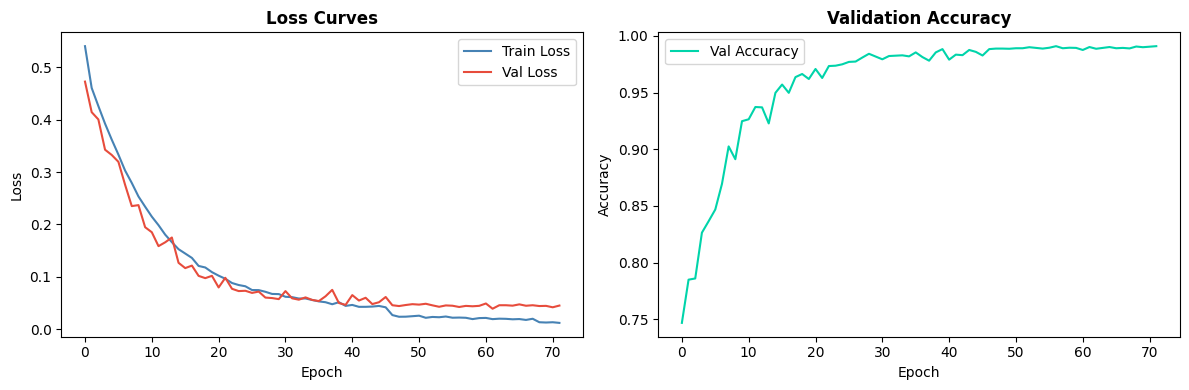

In [206]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train Loss", color="steelblue")
axes[0].plot(val_losses,   label="Val Loss",   color="#e74c3c")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(val_accs, color="#00d4aa", label="Val Accuracy")
axes[1].set_title("Validation Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/plots/training_curves.png", dpi=150)
plt.show()
print("Training curves saved!")

**Evaluate HepaXAI on Test Set**

In [207]:
# Load best model
model.load_state_dict(torch.load(f"{MODEL_PATH}/hepaxai_best.pt"))
model.eval()

with torch.no_grad():
    risk, stage, severity = model(
        X_test_clin.to(device),
        X_test_lab.to(device),
        X_test_bio.to(device))

y_pred = (risk.cpu().numpy() > 0.5).astype(int)
y_prob = risk.cpu().numpy()

print("=" * 55)
print("HepaXAI — TEST SET RESULTS")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred,target_names=["No Disease", "Liver Disease"]))

HepaXAI — TEST SET RESULTS
Accuracy: 0.9904
F1-Score: 0.9904
AUC-ROC: 0.9988
Classification Report:
               precision    recall  f1-score   support

   No Disease       0.99      0.99      0.99      3288
Liver Disease       0.99      0.99      0.99      3288

     accuracy                           0.99      6576
    macro avg       0.99      0.99      0.99      6576
 weighted avg       0.99      0.99      0.99      6576



**Baseline Models (LR, RF, XGBoost)**

In [208]:
baselines = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42,eval_metric="logloss", verbosity=0)
}

results = {}

for name, clf in baselines.items():
    clf.fit(X_train, y_train)
    y_pred_bl = clf.predict(X_test)
    y_prob_bl = clf.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy" : round(accuracy_score(y_test, y_pred_bl), 4),
        "F1-Score" : round(f1_score(y_test, y_pred_bl), 4),
        "AUC-ROC"  : round(roc_auc_score(y_test, y_prob_bl), 4)
    }
    print(f"{name}: Acc={results[name]["Accuracy"]} | "
          f"F1={results[name]["F1-Score"]} | "
          f"AUC={results[name]["AUC-ROC"]}")

Logistic Regression: Acc=0.713 | F1=0.6561 | AUC=0.7682
Random Forest: Acc=0.9985 | F1=0.9985 | AUC=1.0
XGBoost: Acc=0.9971 | F1=0.9971 | AUC=1.0


In [209]:
# Add HepaXAI to results
results["HepaXAI (ours)"] = {
    "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
    "F1-Score" : round(f1_score(y_test, y_pred), 4),
    "AUC-ROC": round(roc_auc_score(y_test, y_prob), 4)
}

# Display comparison table
results_df = pd.DataFrame(results).T
print("" + "="*55)
print("BASELINE COMPARISON")
print("="*55)
print(results_df.to_string())

# Save results
results_df.to_csv(f"{SAVE_PATH}/model_results.csv")
print("Results saved!")

BASELINE COMPARISON
                     Accuracy  F1-Score  AUC-ROC
Logistic Regression    0.7130    0.6561   0.7682
Random Forest          0.9985    0.9985   1.0000
XGBoost                0.9971    0.9971   1.0000
HepaXAI (ours)         0.9904    0.9904   0.9988
Results saved!


FileNotFoundError: [Errno 2] No such file or directory: '../data/plots/model_comparison.png'

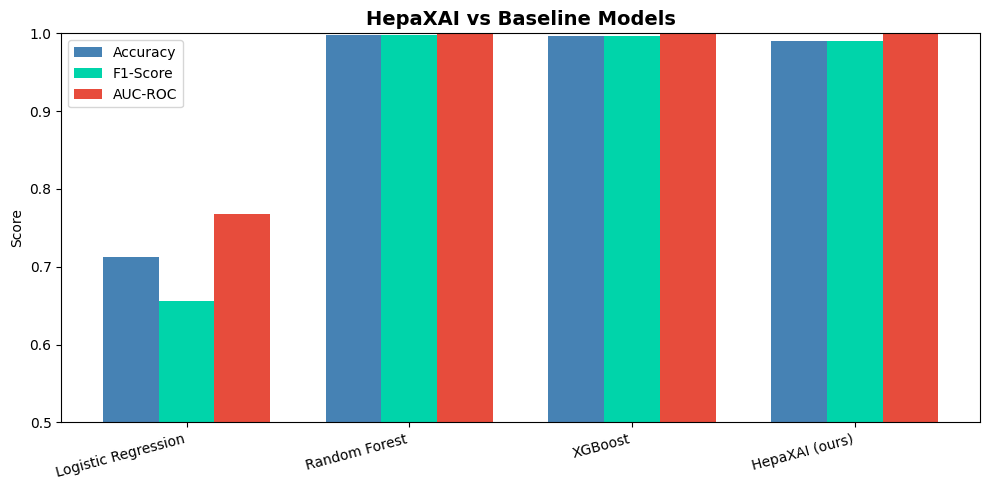

In [210]:
# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df["Accuracy"], width, label="Accuracy", color="steelblue")
bars2 = ax.bar(x,results_df["F1-Score"], width,label="F1-Score", color="#00d4aa")
bars3 = ax.bar(x + width,  results_df["AUC-ROC"],  width,label="AUC-ROC", color="#e74c3c")

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha="right")
ax.set_ylim(0.5, 1.0)
ax.set_title("HepaXAI vs Baseline Models", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.legend()

plt.tight_layout()
plt.savefig("../data/plots/model_comparison.png", dpi=150)
plt.show()
print("Comparison plot saved!")